## Project Understanding

### Company Overview

Alpha Quants is a quantitative risk management, data science and natural language processing firm specialized in financial risk management and actuarial science.
A team of unique quality with:
- Decades of a experience from inside the financial and reinsurance industry.
- Developers , AI experts with extensive financial and quantitative knowledge.



### Business Problem

AlphaQuant has a very extensive data which requires to be transformed into meaningful analysis,identifying trends,evaluate stock performance,identify investment opportunities and make data-driven decision.

### Project Objectives:
- Stocks with highest returns
- Stocks with high volatility
- Study trading volume and its impact
- Future prediction
- Study stocks with similar trading behaviour
- Sectors that perform best
- Stocks not following the average market tred

### Scope
- Loading the dataset
- Cleaning the Data
- Exploratory Data Analaysis
- Feature Engineering
- Machine Learning
- Data visualization
- Business Insights

### Business Questions
-	Which stocks delivered the highest returns?
-	Which stocks were the most volatile?
-	How do trading volumes impact price movement?
-	Can future closing prices be predicted?
-	Which stocks show similar trading behavior?
-	Which sectors (if sector mapping is added) outperform the market?
-	Which stocks exhibit abnormal price movements?


### Expected Outcomes
- Stocks with highest return
- Stocks with more volatility
- Trading values impacting on price movement
- Forecasted prices
- Next decision driven investment opportunity
- Stokcs not moving with average trend

# Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load_csv

In [ ]:
df = pd.read_csv("S&P 500 Stock Prices 2014-2017.csv") # Loading the file
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


### Dataset shape

In [ ]:
df.shape # dataset shape(rows,columns)
# We have 497472 rows and 7 colmuns

(497472, 7)

### First Record

In [4]:
first_record =df.head(1) 
last_record = df.tail(1) 
first_record # first record


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.07,25.82,25.06,25.36,8998943


### Last Record

In [5]:
last_record # last record

,symbol,date,open,high,low,close,volume
497471,ZTS,2017-12-29,72.55,72.76,72.04,72.04,1704122


### Data Types

In [6]:
info = df.info()
info # checking data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


### Missing Values

In [7]:
missing_value = df.isnull().sum()
missing_value  # checking missing values   # open = 11 missing values, higfh = 8 missing values , low = 8 missing values

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

### Duplicate Records

In [8]:
duplicate_records = df.duplicated().sum()
print(duplicate_records) # no duplicate record


0


### Descriptive Statistics

In [9]:
descriptive_stats = df.describe()
descriptive_stats # descriptive statistics

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


### Unique Stocks

In [ ]:
unique = df["symbol"].nunique() #number of unique stocks
unique
 

505

### Date Range

In [11]:
df["date"] = pd.to_datetime(df["date"]) # converted date time (type object) to (date_time)
df = df.sort_values(by= "date",ascending = True)
print(f"start date :{ df["date"].min()} and end date :{df["date"].max()}")

start date :2014-01-02 00:00:00 and end date :2017-12-29 00:00:00


# Data Cleaning

### Date conversion
- Date column has been checked and it has been been converted from object type to datetime type.

### Remove duplicate rows
- The dataset was check and there no duplicate rows that were found. So there is no duplicate to remove.

### Handle missing values


In [12]:
df[["open","high","low"]] = df[["open","high","low"]].fillna(df[["open","high","low"]].median()) 

  ##### Replace the missing values of dimesnions "open,high and low" by using median as it will be less likely affected by outliers

### Sort Data

In [ ]:
df = df.sort_values(by= ["date","symbol"],ascending= True) #sorting values from small to big and letters accordingly

In [14]:
df.head()

,symbol,date,open,high,low,close,volume
57,A,2014-01-02,57.1000,57.1000,56.1500,56.2100,1916160
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061


### Reset Index

In [ ]:
df.reset_index(inplace = True,drop = True) #Resetting to new index and dropping the old index
df.head()

,symbol,date,open,high,low,close,volume
0,A,2014-01-02,57.1000,57.1000,56.1500,56.2100,1916160
1,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
4,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061


### Validating price columns

In [ ]:
invalid_high = df[
            df["high"] != df[["open","high","low","close"]].max(axis= 1)] # finding out the invalid data
invalid_high


,symbol,date,open,high,low,close,volume
45502,AOS,2014-05-19,23.89,23.595,23.8500,24.4450,1944854
166349,VRTX,2015-05-12,64.97,65.560,64.3537,124.0800,569747
175559,REGN,2015-06-09,64.97,65.560,64.3537,526.0900,12135
188576,ES,2015-07-17,64.97,48.490,47.8500,47.9200,1246786
188755,O,2015-07-17,64.97,47.310,46.8300,46.9900,1229513
249224,DHR,2016-01-12,64.97,65.560,64.3537,88.5500,0
442107,BHF,2017-07-26,64.97,65.560,64.3537,69.0842,3


In [ ]:
invalid_low = df[
            df["low"] != df[["open","high","low","close"]].min(axis = 1)]  # finding out the invalid data
invalid_low

,symbol,date,open,high,low,close,volume
45502,AOS,2014-05-19,23.890,23.5950,23.8500,24.4450,1944854
45549,CHD,2014-05-19,18.770,33.9525,33.6950,33.8950,1078888
48773,SPG,2014-05-28,176.230,176.6000,174.5000,165.4200,1383759
59619,CHK,2014-06-30,30.430,31.1000,30.3700,29.3900,8132836
60251,IP,2014-07-01,50.850,51.0700,50.5700,50.0900,5624981
79809,O,2014-08-27,44.675,44.7000,44.6600,44.5272,185518
103985,DHR,2014-11-06,78.470,81.3050,80.4900,81.2600,1614419
104191,O,2014-11-06,44.740,47.5700,46.7300,46.8600,1803132
182011,WRK,2015-06-26,64.970,65.5600,64.3537,61.9000,100
188548,DHR,2015-07-17,64.970,88.7600,88.2400,88.7200,2056819


# Exploratory Data Analysis

## Number of companies

In [ ]:
number_of_comp = df["symbol"].nunique()   #total no of companies for analysis
print(f"Number of companies : {number_of_comp}")

Number of companies : 505


## Trading days

In [ ]:
trading_days = df["date"].nunique()    #finding out the number of trading days
print(f"Trading days : {trading_days}")

Trading days : 1007


## Highest closing price

In [ ]:
highest_closing_price = df["close"].max()  # finding out the highest closing price
print(f"Highest closing price : {highest_closing_price}")

Highest closing price : 2049.0


## Lowest closing price

In [ ]:
lowest_closing_price = df["close"].min()      # finding out the lowest closing price
print(f"Lowest closing price : {lowest_closing_price}")

Lowest closing price : 1.59


## Average closing price

In [ ]:
average_closing_price = df["close"].mean()   #finding out the average closing price
print(f"Average closing price : {average_closing_price}")

Average closing price : 86.36908207456902


## Total trading volume

In [ ]:
total_trading_volume = df["volume"].sum()   #finding out the total trading volume
print(f"Total trading volume : {total_trading_volume}")

Total trading volume : 2116052320539


## Company Analysis

### Top 20 companies by average closing price

In [ ]:
top_20_average = df.groupby("symbol")["close"].mean()   # finding out the top 20 companies with highest closing price
top_20_average.sort_values(ascending = False,inplace = True)
top_20_average.head(20)


symbol
PCLN     1390.272642
GOOGL     722.559017
GOOG      714.496848
AZO       660.246425
AMZN      619.244787
CMG       516.849355
REGN      412.335822
MTD       377.854131
BLK       359.971301
BIIB      310.474882
EQIX      309.171057
SHW       276.096356
ADS       250.675124
AGN       244.738898
TDG       228.340268
GWW       225.180000
LMT       224.288083
CHTR      224.250779
ORLY      222.626023
ESS       219.035432
Name: close, dtype: float64

1. Top 20 comapanies having higher average closing price can be identified as long term opportunity investment.
2. It suggests more long term stable growth.
3. Investors can focus on this companies for long term wealth.

### Top traded companies

In [ ]:
top_traded_companies = df.groupby("symbol")["volume"].sum().sort_values(ascending = False) # top 10 companies wqhose trading is higher than others
top_traded_companies.head(10)

symbol
BAC     89988444028
AAPL    45485758169
GE      41734050117
AMD     33522535638
F       33144701045
MSFT    30927601441
FB      29432418373
MU      28158553783
CHK     28080599383
INTC    27351266285
Name: volume, dtype: int64

1. High trading companies suggests investors stronmg interest in these stocks
2. These mnarkets are highly preferred by investors as these stovks are highly liquid.
3. these stocks suggests high buy and sell and attracts more participants

### Highest volume companies

In [ ]:
highest_volume_companies = df.groupby("symbol")["volume"].max() # top 10 companies whose volume is highets
highest_volume_companies.sort_values(ascending= False,inplace = True)
highest_volume_companies.head(10)

symbol
VZ      618237630
GE      431332632
BAC     375088650
PFE     284468054
MRO     273996613
AMD     268336455
AAPL    266833581
KMI     251563883
AMAT    219415189
MSFT    202526536
Name: volume, dtype: int64

1. These companies suggests high single day trading.
2. It causes maybe various reasons such as big annouchment,loan clearation,acquisition, new board of directors or market trend.s
3. These companies helps market partcipants and investors get an idea of future investment activities.

### Daily return distribution

In [ ]:
df["daily_return_dist"] = (df["close"]/df["open"])-1  # new column added to find out the % of daily return
df["daily_return_dist"].head()

0   -0.015587
1    0.011568
2   -0.005618
3   -0.004589
4   -0.002686
Name: daily_return_dist, dtype: float64

In [ ]:
df["daily_return_dist"].describe()  # gives us as an idea where majority data lies

count    497472.000000
mean          0.000322
std           0.016815
min          -0.492185
25%          -0.006256
50%           0.000414
75%           0.007051
max           7.097430
Name: daily_return_dist, dtype: float64

## Time Analysis

### Monthly Trends


In [ ]:
df["year_month"] = df["date"].dt.to_period("M") # converted dates to month with months as index
monthly_trends = df.groupby("year_month").agg({
    "volume": "sum",
    "close": "mean"
})
monthly_trends.head(4)

,volume,close
year_month,,
2014-01,50255306758,71.825667
2014-02,45137208436,72.859147
2014-03,44892863157,74.899410
2014-04,47939618962,74.578316


### Quarter Trends

In [ ]:
df["year_quarter"] = df["date"].dt.to_period("Q") #converted date to quarter with quarters as index
quarter_trends = df.groupby("year_quarter").agg({
    "volume":"sum",
    "close":"mean"
})
quarter_trends.head()


,volume,close
year_quarter,,
2014Q1,140285378351,73.205917
2014Q2,123782541057,75.910311
2014Q3,113236130105,78.672397
2014Q4,132347490642,79.859102
2015Q1,129770209275,83.658978


### Yearly Trends

In [ ]:
df["date_year"] = df["date"].dt.to_period("Y") # converted dates to year with years as index
yearly_trends = df.groupby("date_year").agg({
    "volume":"sum",
    "close":"mean"
})
yearly_trends

,volume,close
date_year,,
2014,509651540155,76.969836
2015,534954787348,84.134718
2016,571045692991,85.253095
2017,500400300045,98.800312


## Volatility Analysis

### Daily Returns

In [32]:
df["daily_return"] = (df['close']/df["open"])-1
df[["open","close","daily_return"]].head()

,open,close,daily_return
0,57.1000,56.2100,-0.015587
1,25.0700,25.3600,0.011568
2,110.3600,109.7400,-0.005618
3,79.3828,79.0185,-0.004589
4,52.1200,51.9800,-0.002686


In [ ]:
highest_daily_return = df["symbol"][df["daily_return"]==df["daily_return"].max()] # filter out company whose daily return is the highest out of 505 companies.
print(highest_daily_return)

175559    REGN
Name: symbol, dtype: object


### Rolling Standard Deviation

In [ ]:
df["rolling_std_5"] = df.groupby("symbol")["daily_return"].transform(lambda x : x.rolling(window = 5).std()) # taken out standard deviation of daily return by considering 5 working days
df["rolling_std_5"].tail(10)

497462    0.003958
497463    0.008991
497464    0.002327
497465    0.006304
497466    0.005958
497467    0.004553
497468    0.005243
497469    0.007925
497470    0.006762
497471    0.002566
Name: rolling_std_5, dtype: float64

1. It tells us the volatitlity of the market on a weekly basis
2. Higher values indicate high volatility and lower value indicates lower volatility.
3. Different type of investors would go for decision making based on their risk capacity by through looking at the volatility

### Moving Average

In [81]:
df["moving_average_7"] = df.groupby("symbol")["close"].transform(lambda x : x.rolling(window = 7).mean())# taken out average of close price by considering 7 working days
df.head()

,symbol,date,open,high,low,close,volume,daily_return_dist,year_month,year_quarter,...,moving_average_30,cumulative_return,previous_day_close,Price difference,high_low_spread,lag_1,lag_2,lag_5,rolling_max,rolling_min
0,A,2014-01-02,57.1000,57.1000,56.1500,56.2100,1916160,-0.015587,2014-01,2014Q1,...,NaN,-0.015587,NaN,-0.8900,0.9500,NaN,NaN,NaN,NaN,NaN
1,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,0.011568,2014-01,2014Q1,...,NaN,0.011568,NaN,0.2900,0.7600,NaN,NaN,NaN,NaN,NaN
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,-0.005618,2014-01,2014Q1,...,NaN,-0.005618,NaN,-0.6200,2.5900,NaN,NaN,NaN,NaN,NaN
3,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,-0.004589,2014-01,2014Q1,...,NaN,-0.004589,NaN,-0.3643,0.7155,NaN,NaN,NaN,NaN,NaN
4,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,-0.002686,2014-01,2014Q1,...,NaN,-0.002686,NaN,-0.1400,0.8100,NaN,NaN,NaN,NaN,NaN


In [ ]:
df["moving_average_30"] = df.groupby("symbol")["close"].transform(lambda x : x.rolling(window = 30).mean()) # taken out average of close price by considering 30 working days

### Cumulative return

In [82]:
df["cumulative_return"] = (1+df["daily_return"]).groupby(df["symbol"]).cumprod()-1 # taken out the cumulative return to check continuous performance from time to time

df.head(4)

,symbol,date,open,high,low,close,volume,daily_return_dist,year_month,year_quarter,...,moving_average_30,cumulative_return,previous_day_close,Price difference,high_low_spread,lag_1,lag_2,lag_5,rolling_max,rolling_min
0,A,2014-01-02,57.1000,57.1000,56.1500,56.2100,1916160,-0.015587,2014-01,2014Q1,...,NaN,-0.015587,NaN,-0.8900,0.9500,NaN,NaN,NaN,NaN,NaN
1,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,0.011568,2014-01,2014Q1,...,NaN,0.011568,NaN,0.2900,0.7600,NaN,NaN,NaN,NaN,NaN
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,-0.005618,2014-01,2014Q1,...,NaN,-0.005618,NaN,-0.6200,2.5900,NaN,NaN,NaN,NaN,NaN
3,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,-0.004589,2014-01,2014Q1,...,NaN,-0.004589,NaN,-0.3643,0.7155,NaN,NaN,NaN,NaN,NaN


1. Cumulative returns tells us the overal growth of an investment over time.
2. Positive signal means company is good overall according the time analsysis while negative tells use the the company is not performing well.
3. It helps investors make buy and sell decisions.


# Data Visualization

#### Line charts

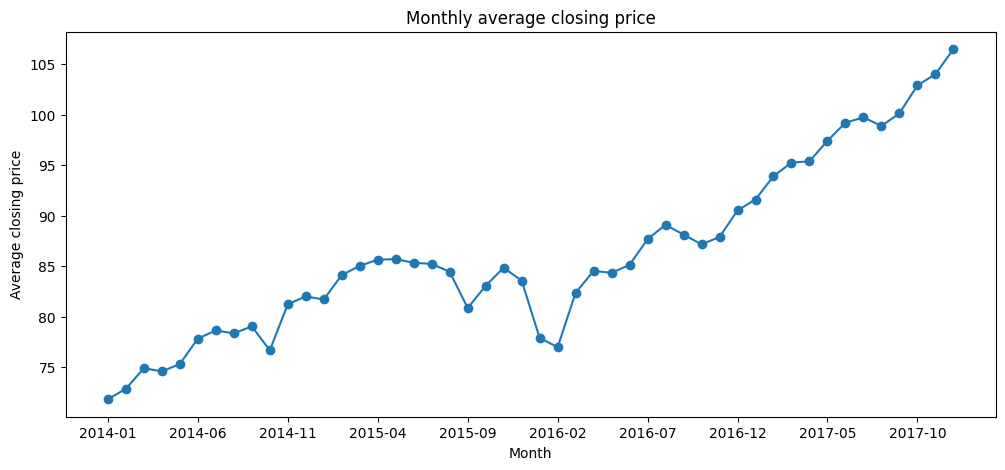

In [38]:
plt.figure(figsize = (12,5))
plt.plot(monthly_trends.index.astype(str),monthly_trends["close"],marker = "o")
plt.title("Monthly average closing price")
plt.xlabel("Month")
plt.ylabel("Average closing price")
plt.xticks(monthly_trends.index.astype(str)[::5])
plt.show()

1. Monthly average close price is going on a positive trend.
2. It represents steady market growth.
3. Prices from 75  to 80 the market went on a steady growth.
4. It face decline during 2015 to early 2016 where it fell 80 to 75 to make a temporary market correction.
5. IT recovered its fall and reached highest closing price till 106.
6. Overall its S&P 500 comppanies performance is great and it suggests long term growth.

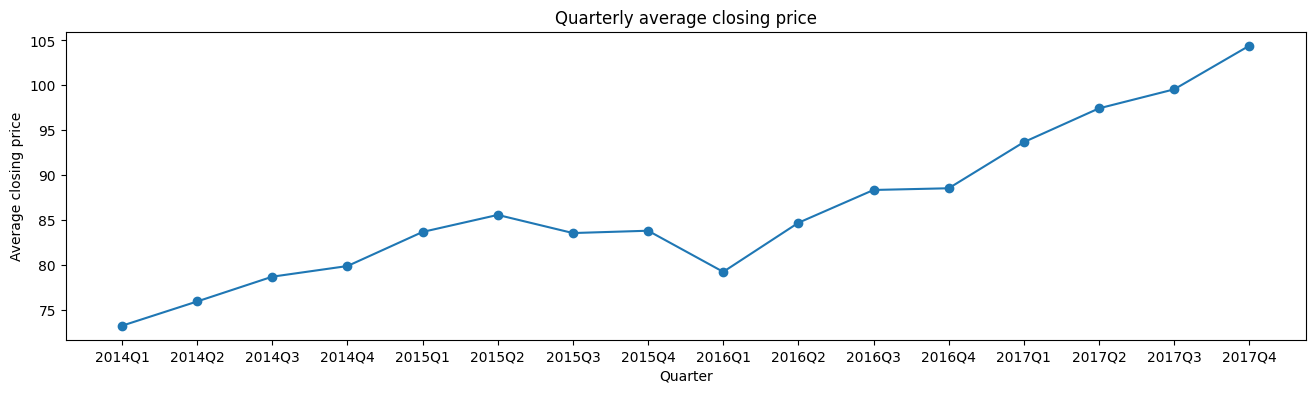

In [39]:
plt.figure(figsize = (16,4))
plt.plot(quarter_trends.index.astype(str),quarter_trends["close"],marker = 'o')
plt.title("Quarterly average closing price")
plt.xlabel("Quarter")
plt.ylabel("Average closing price")
plt.xticks(quarter_trends.index.astype(str))
plt.show()

1. Quaterly data shows a steady market growth.
2. Between 2015-2016 there is fell in price suggesting market correction.
3. Overall the S&P 500 companies are performing greats quaterly and suggest good stable growth

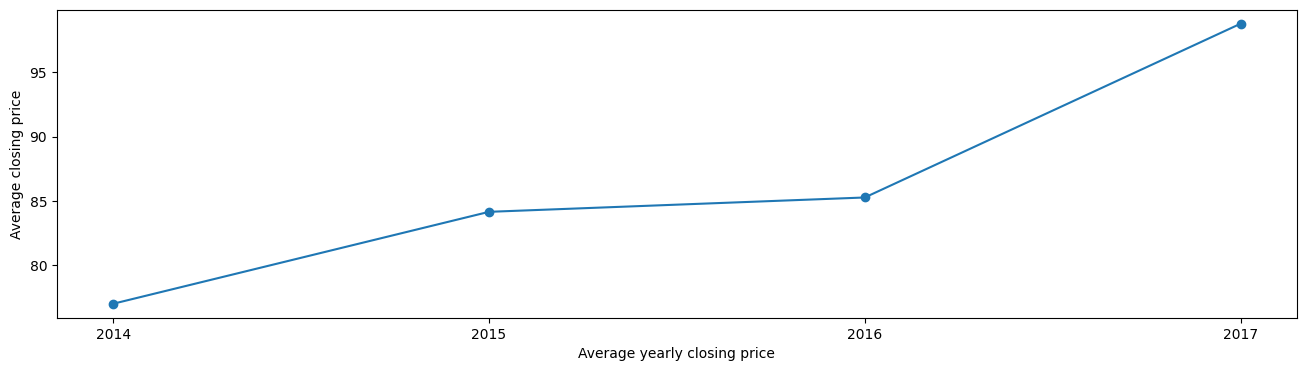

In [40]:
plt.figure(figsize = (16,4))
plt.plot(yearly_trends.index.astype(str),yearly_trends["close"],marker = "o")
plt.xlabel("Average yearly closing price")
plt.ylabel("Average closing price")
plt.show()

1. Steady market Growth Yearly.
2. Between 2015-2016 the growth pace has reduced but overall it perfom great after 2016.
3. Performance of S&P 500 imporved and suggests positive growth during the analyzed period

#### Histogram

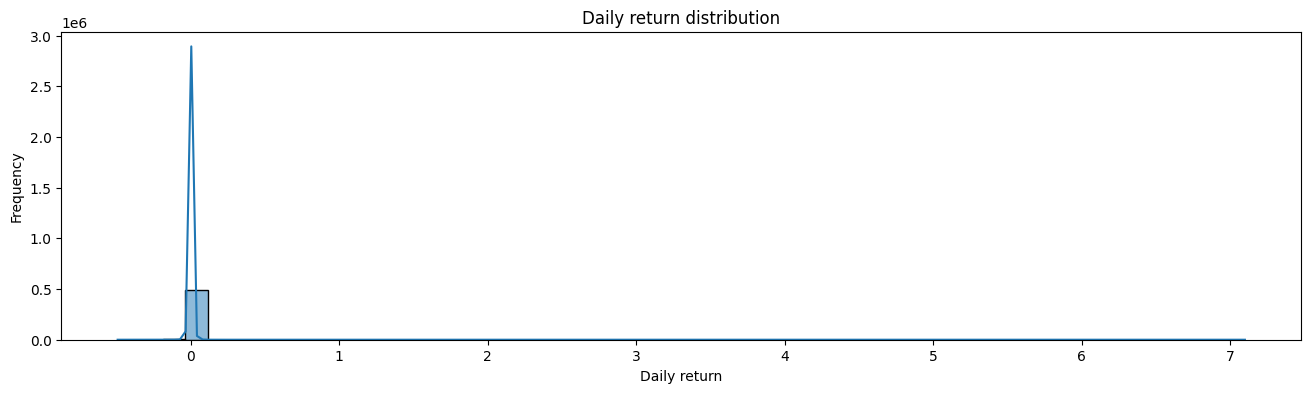

In [41]:
plt.figure(figsize= (16,4))
sns.histplot(df["daily_return"],bins = 50,kde = True)
plt.title("Daily return distribution")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.show()

1. Mostly the daily return of the companies are very close to 0.
2. Large prices changes are very rare.
3. There are outliers but majority of the datas are concentrated around 0 with occasiaonal fluctuations. 

#### Box Plot

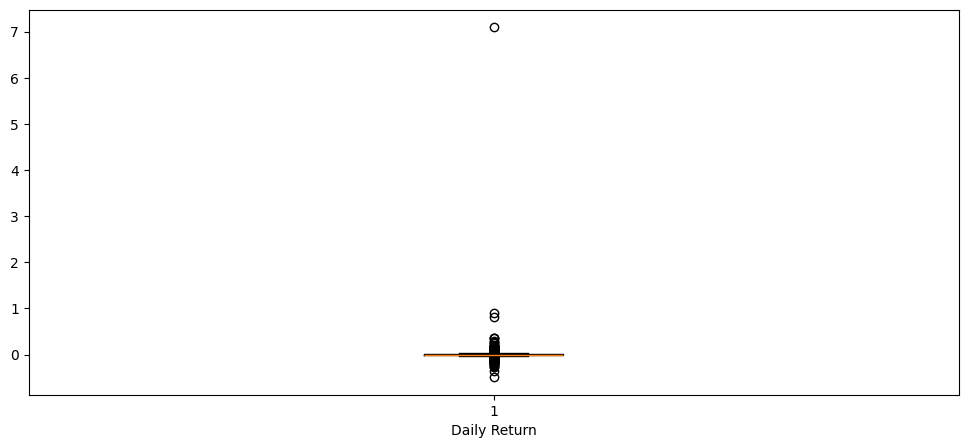

In [42]:
plt.figure(figsize = (12,5))
plt.boxplot(df["daily_return"])
plt.xlabel("Daily Return")
plt.show()

1. Most of the data return lies in the median which suggests returns are almost minimal and stable
2. There are outliers in which daily return tends to be extreme
3. Largest outlier of daily return is 7 which is abnormal compared to others.
   

### Correlation

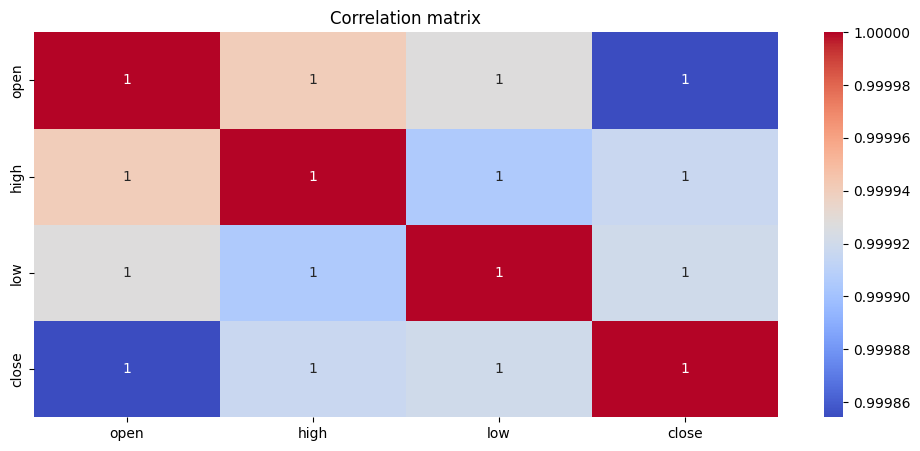

In [43]:
correlation = df[["open","high","low","close"]].corr()

plt.figure(figsize = (12,5))
sns.heatmap(correlation,annot = True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

1. The open,high,low and close prices are highly positively coorelated to one another.
2. Each price variable tends to move in the same direction over time.
3. The strong positive corelation suggest that almost every information,market conditions and external confditions effects has its impacts on the dimensions equally creating the same price movement trend.

In [44]:
df.head(2)

,symbol,date,open,high,low,close,volume,daily_return_dist,year_month,year_quarter,date_year,daily_return,rolling_std_5,moving_average_7,moving_average_30,cumulative_return
0,A,2014-01-02,57.10,57.10,56.15,56.21,1916160,-0.015587,2014-01,2014Q1,2014,-0.015587,NaN,NaN,NaN,-0.015587
1,AAL,2014-01-02,25.07,25.82,25.06,25.36,8998943,0.011568,2014-01,2014Q1,2014,0.011568,NaN,NaN,NaN,0.011568


### Scatter plot

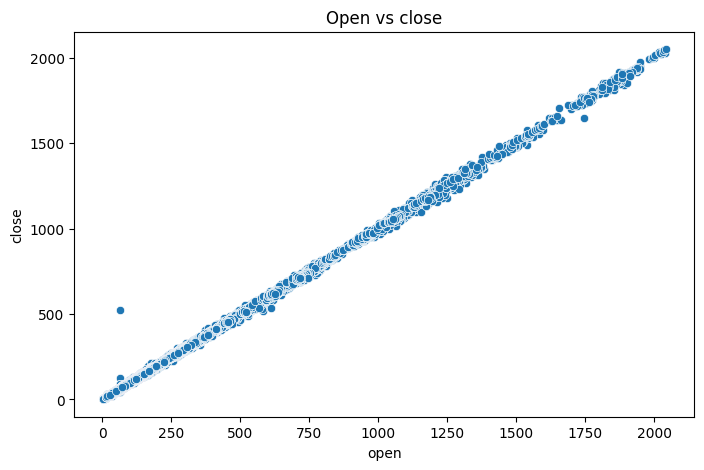

In [45]:
plt.figure(figsize = (8,5))
sns.scatterplot(x = df["open"] ,y =df["close"])
plt.title("Open vs close")
plt.show()


1. Open and close are positively corelated.
2. Showing an upward trend
3. Few outliers exist maybe because of market fluctuations,unususal market activities,etc.

### Rolling average

In [46]:
top_company = df.groupby("symbol")["volume"].sum().idxmax()
top_company

'BAC'

In [47]:
company = df[df["symbol"]==top_company]
company.head(1)

,symbol,date,open,high,low,close,volume,daily_return_dist,year_month,year_quarter,date_year,daily_return,rolling_std_5,moving_average_7,moving_average_30,cumulative_return
59,BAC,2014-01-02,15.69,16.16,15.68,16.1,149225696,0.026131,2014-01,2014Q1,2014,0.026131,NaN,NaN,NaN,0.026131


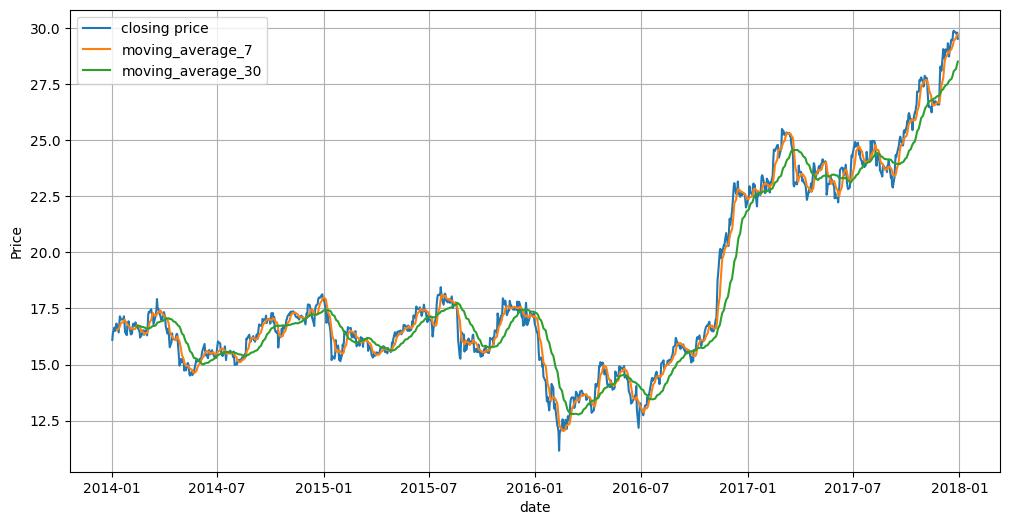

In [48]:
plt.figure(figsize=(12,6))
plt.plot(company["date"],company["close"],label ="closing price")
plt.plot(company["date"],company["moving_average_7"],label ="moving_average_7")
plt.plot(company["date"],company["moving_average_30"],label ="moving_average_30")
plt.xlabel("date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

1. It shows upward trend
2. Moving average 7 crossing over moving average 30 shows an upward trend.
3. Moving average 7 crossing 30 mostly shows upward trend movement.

In [49]:
df.head(0)

,symbol,date,open,high,low,close,volume,daily_return_dist,year_month,year_quarter,date_year,daily_return,rolling_std_5,moving_average_7,moving_average_30,cumulative_return


### Volume Trends

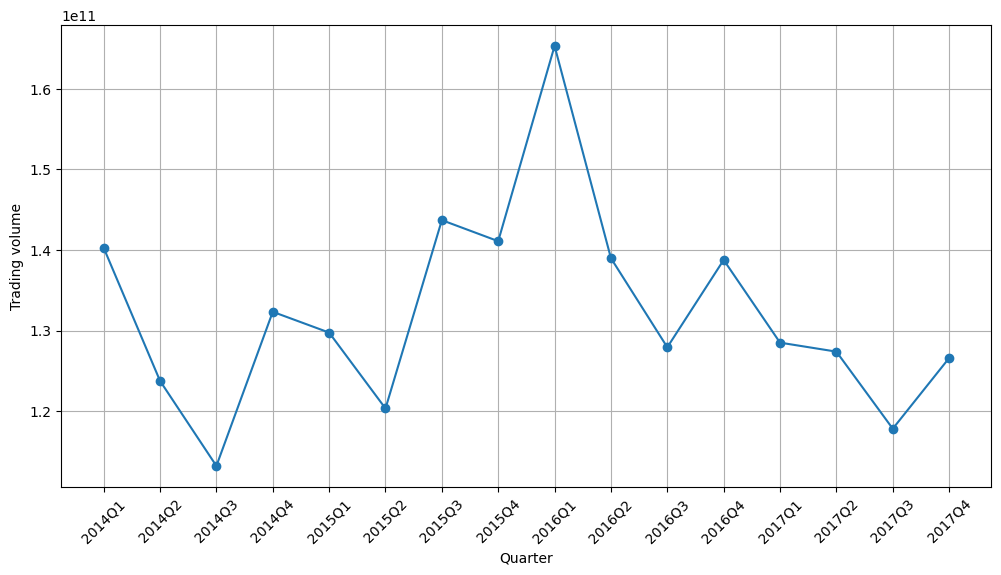

In [50]:
plt.figure(figsize=(12,6))
plt.plot(quarter_trends.index.astype(str),quarter_trends["volume"],marker="o")
plt.xlabel("Quarter")
plt.ylabel("Trading volume")
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

1. It shows the trading activities.
2. Trading activities increased during the period from 2014 Q3 - 2016 Q1 with minor deep in trading activities.
3. It reached its peek on 2016Q1 and then trading activities decline.
4. Overall the market participation is calmer and more stable during the analysis period.

# Feature Engineering

•	Daily Return
•	7-Day Moving Average
•	30-Day Moving Average
•	Rolling Mean
•	Volatility
It has been executed on the previous sections.

### Previous day close

In [ ]:
df["previous_day_close"] = df.groupby("symbol")["close"].shift(1) # Previous closing price selected on current day.
df.head(2)

,symbol,date,open,high,low,close,volume,daily_return_dist,year_month,year_quarter,date_year,daily_return,rolling_std_5,moving_average_7,moving_average_30,cumulative_return,previous_day_close
0,A,2014-01-02,57.10,57.10,56.15,56.21,1916160,-0.015587,2014-01,2014Q1,2014,-0.015587,NaN,NaN,NaN,-0.015587,NaN
1,AAL,2014-01-02,25.07,25.82,25.06,25.36,8998943,0.011568,2014-01,2014Q1,2014,0.011568,NaN,NaN,NaN,0.011568,NaN


### Price difference / Open-Close difference

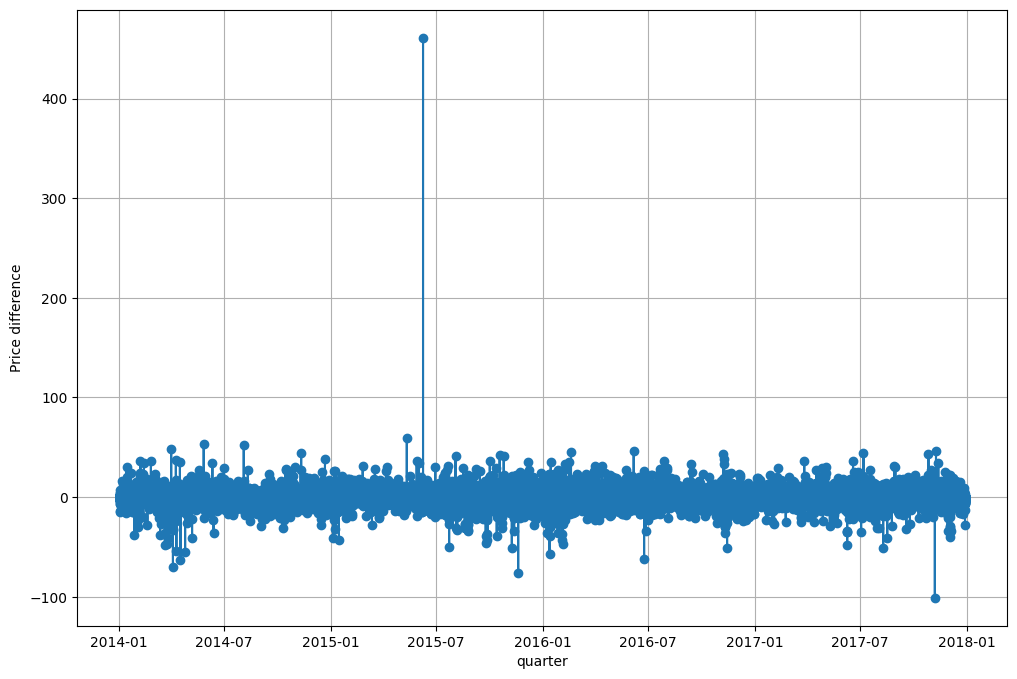

In [52]:
df["Price difference"]= df["close"]-df["open"]
df[["open","close","Price difference"]].head(2)

plt.figure(figsize =(12,8))
plt.plot(df["date"],df["Price difference"],marker = "o")
plt.xlabel("quarter")
plt.ylabel("Price difference")
plt.grid(True)
plt.show()


1. Price difference = Positive means stocks gained guring the day # while looking at the columns
2. Price difference = Negative means stocks lost during the day # while looking at the columns
3. Maximum stocks price difference are close to one another which suggests price difference are setady and there small fluctuations. 

### High low spread

In [ ]:
df["high_low_spread"]= df["high"]-df["low"] # difference between high and low shows the gap.
df["high_low_spread"].head()

0    0.9500
1    0.7600
2    2.5900
3    0.7155
4    0.8100
Name: high_low_spread, dtype: float64

### Lag Features

In [54]:
df["lag_1"] = df["previous_day_close"] # Previous day (1 day before analysis)
df["lag_2"] = df.groupby("symbol")["close"].shift(2) # Previous 2 days (2 days analysis)
df["lag_5"] = df.groupby("symbol")["close"].shift(5) # Previous 5 days(weekly analysis)


### Rolling mean
1.It is created as Moving_average_7 & Moving_average_30    
  

### Rolling Maximum

In [ ]:
df["rolling_max"] = df.groupby("symbol")["close"].transform(lambda x : x.rolling(window = 5).max()) # closing price of companies with maximum comapred to 5 working days
# comparision of values with week performance

### Rolling minimum

In [56]:
df["rolling_min"] = df.groupby("symbol")["close"].transform(lambda x : x.rolling(window = 5).min())
# comparision of values with week performance

# Statitstical Analysis

### Covariance matrix

In [57]:
cov_matrix = df[["open","high","low","close"]].cov()
print(cov_matrix)

               open          high           low         close
open   10296.192507  10380.926017  10204.133069  10294.919939
high   10380.926017  10467.597129  10288.490197  10380.905224
low    10204.133069  10288.490197  10114.361970  10204.282017
close  10294.919939  10380.905224  10204.282017  10296.649459


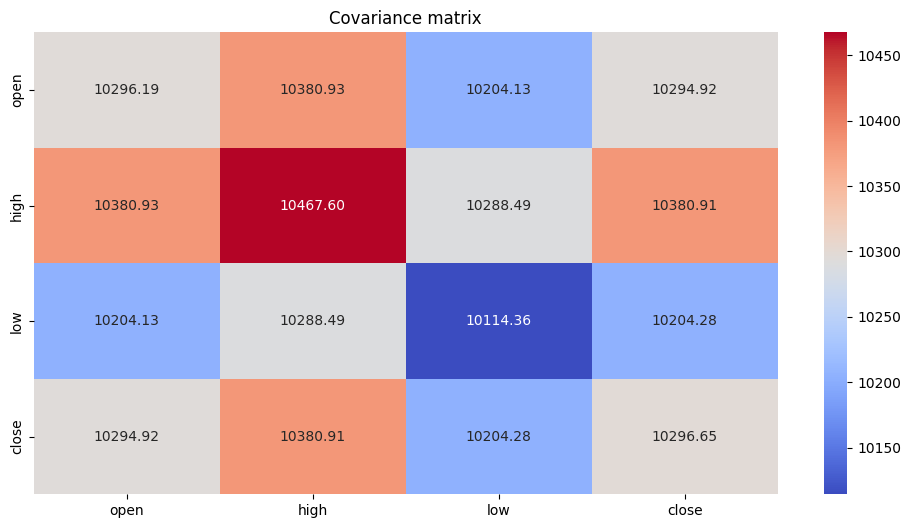

In [58]:
plt.figure(figsize = (12,6))
sns.heatmap(cov_matrix,annot= True,fmt =".2f",cmap = 'coolwarm')
plt.title("Covariance matrix")
plt.show()

1. All the covariance values are positive which implies they all move in the same direction.
2. Comparision between open and high shows a strong positive signal(10467.60) which means stocks opening at high prices tend to reach higher highs.
3. Comparision between open and close shows a strong positive signal(10294.92) which means stocks opening at high prices tend to associate with higher closing prices


### Skewness

In [93]:
skewness = df["daily_return"].skew()
print(f"skewness: {skewness}")

skewness: 151.6421668117097


### Kurtosis

In [92]:
kurtosis = df["daily_return"].kurt()
print(f"kurtosis: {kurtosis}")

kurtosis: 63819.705713611795


1. Skewness indicates that the daily return distribution is rightly skewed which means a small number of companies made abnormal postive returns compared to the majority.
2. Kurtosis proves that there are outliers present which suggests abnormal price movements.

# Machine Learning

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error, r2_score,mean_absolute_percentage_error


### Regression Model

#### Linear regression 

In [61]:
df.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume',
       'daily_return_dist', 'year_month', 'year_quarter', 'date_year',
       'daily_return', 'rolling_std_5', 'moving_average_7',
       'moving_average_30', 'cumulative_return', 'previous_day_close',
       'Price difference', 'high_low_spread', 'lag_1', 'lag_2', 'lag_5',
       'rolling_max', 'rolling_min'],
      dtype='object')

In [62]:
X = df[["open","high","low","volume","moving_average_7","moving_average_30","lag_1","lag_2","lag_5","daily_return"]]
y = df["close"]
X = X.fillna(0)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state= 42)


In [63]:
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)
y_pred_lr = model_lr.predict(X_test)

In [64]:
mae_lr = mean_absolute_error(y_test,y_pred_lr) # linear regression mean absolute error
mse_lr = mean_squared_error(y_test,y_pred_lr) # linear regression mean squared error
rmse_lr = np.sqrt(mse_lr) # linear regression root mean squared error
mape_lr = mean_absolute_percentage_error(y_test,y_pred_lr)
r2_lr = r2_score(y_test,y_pred_lr)

#### Decision Tree Regressor

In [ ]:
model_dt = DecisionTreeRegressor(max_depth = 10,random_state= 42) # used max-depth to no go overfitting and random state to not change values everytime it runs
model_dt.fit(X_train,y_train)
y_pred_dt = model_dt.predict(X_test)

In [66]:
mae_dt = mean_absolute_error(y_test,y_pred_dt) 
mse_dt = mean_squared_error(y_test,y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test,y_pred_dt)
mape_dt = mean_absolute_percentage_error(y_test,y_pred_dt)

#### Random Forest Regressor

In [67]:
df.shape

(497472, 24)

In [ ]:
model_rfr = RandomForestRegressor(n_estimators = 100,max_depth = 10,random_state = 42,n_jobs = -1) # n_ estimators is the number of independent trees created for decision making
model_rfr.fit(X_train,y_train)
y_pred_rfr = model_rfr.predict(X_test)

mae_rfr = mean_absolute_error(y_test,y_pred_rfr)
mse_rfr = mean_squared_error(y_test,y_pred_rfr)
rmse_rfr = np.sqrt(mse_rfr)
r2_rfr = r2_score(y_test,y_pred_rfr)
mape_rfr = mean_absolute_percentage_error(y_test,y_pred_rfr)
print(mae_rfr)
print(mse_rfr)
print(rmse_rfr)
print(r2_rfr)

0.3052342897081735
0.4378813192597741
0.6617260152508545
0.9999575914370269


#### XG Boost

In [69]:
model_xgb = XGBRegressor(n_estimators = 30,max_depth = 6,random_state = 42)
model_xgb.fit(X_train,y_train)
y_pred_xgb =model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test,y_pred_xgb)
mse_xgb = mean_squared_error(y_test,y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test,y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test,y_pred_xgb)


## Model Evaluation

In [70]:
model_summary = pd.DataFrame({
    "Model":["Linear Regression","Decision Tree Regressor","Random Forest Regressor","XG Boost"],
    "MAE":[mae_lr,mae_dt,mae_rfr,mae_xgb],
    "MSE":[mse_lr,mse_dt,mse_rfr,mse_xgb],
    "Rmse":[rmse_lr,rmse_dt,rmse_rfr,rmse_xgb],
    "R2":[r2_lr,r2_dt,r2_rfr,r2_xgb],
    "MAPE":[mape_lr,mape_dt,mape_rfr,mape_xgb]
})
model_summary.round(4)

,Model,MAE,MSE,Rmse,R2,MAPE
0,Linear Regression,0.3669,0.5117,0.7153,1.0000,0.0075
1,Decision Tree Regressor,0.4581,0.9233,0.9609,0.9999,0.0063
2,Random Forest Regressor,0.3052,0.4379,0.6617,1.0000,0.0042
3,XG Boost,1.3798,161.1585,12.6948,0.9844,0.0107


#### Best model will be Random Forest Regressor as it provides the least (MAE,MSE,RMSE & MAPE)
#### Highest R2 exaplains more details.

# Feature Importance

## Random Forest Feature Importance

             Feature    Importance
2                low  6.845766e-01
1               high  3.146274e-01
6              lag_1  3.093702e-04
0               open  2.275417e-04
7              lag_2  1.558572e-04
9       daily_return  3.888599e-05
5  moving_average_30  2.667600e-05
4   moving_average_7  2.492085e-05
8              lag_5  1.191504e-05
3             volume  7.568776e-07


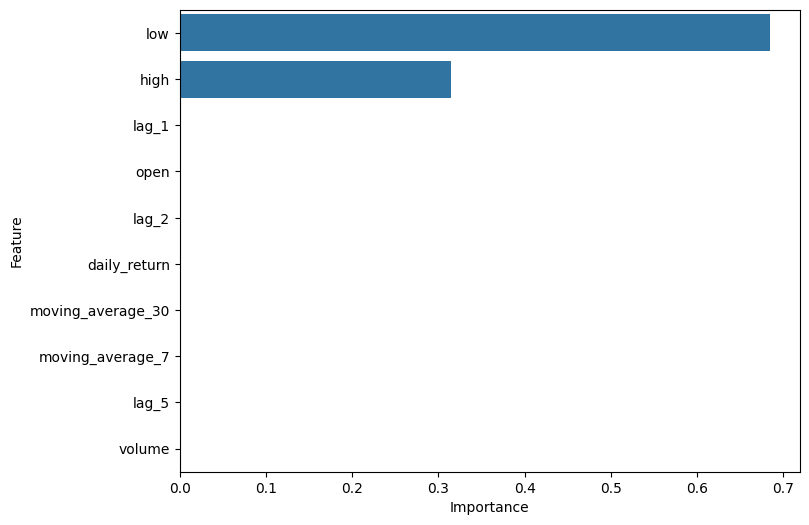

In [71]:
feature_importance = pd.DataFrame({
"Feature": X.columns,
"Importance":model_rfr.feature_importances_})
feature_importance.sort_values(by="Importance",ascending= False,inplace= True)
print(feature_importance)
plt.figure(figsize = (8,6))
sns.barplot(data = feature_importance,x = "Importance",y ="Feature" )
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

 1. The low price has the highest influnce on closing price(68.4%)
 2. The high price has the second highest influence on closing price.(31.4%)
 3. The feature engineering columns has very minimal effect on closing price.
 4. Overall the strongest determinant to chaanging closing price is high and low.

# Time Series Analysis    

### Resample by Month

In [72]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

In [73]:
stock_symbol = "AAPL"

stock_df = df[df["symbol"] == stock_symbol].copy()

# Set date as index
stock_df.set_index("date", inplace=True)

stock_df.head()

,symbol,open,high,low,close,volume,daily_return_dist,year_month,year_quarter,date_year,...,moving_average_30,cumulative_return,previous_day_close,Price difference,high_low_spread,lag_1,lag_2,lag_5,rolling_max,rolling_min
date,,,,,,,,,,,,,,,,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957,-0.004589,2014-01,2014Q1,2014,...,NaN,-0.004589,NaN,-0.3643,0.7155,NaN,NaN,NaN,NaN,NaN
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870,-0.021488,2014-01,2014Q1,2014,...,NaN,-0.025978,79.0185,-1.6971,1.8957,79.0185,NaN,NaN,NaN,NaN
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151,0.012057,2014-01,2014Q1,2014,...,NaN,-0.014235,77.2828,0.9257,1.8857,77.2828,79.0185,NaN,NaN,NaN
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766,-0.007868,2014-01,2014Q1,2014,...,NaN,-0.021991,77.7042,-0.6118,1.1478,77.7042,77.2828,NaN,NaN,NaN
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685,0.008630,2014-01,2014Q1,2014,...,NaN,-0.013550,77.1481,0.6643,0.9815,77.1481,77.7042,NaN,79.0185,77.1481


In [74]:
monthly_stock = stock_df["close"].resample("M").mean()

C:\Users\abhin\AppData\Local\Temp\ipykernel_36972\2764350834.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_stock = stock_df["close"].resample("M").mean()


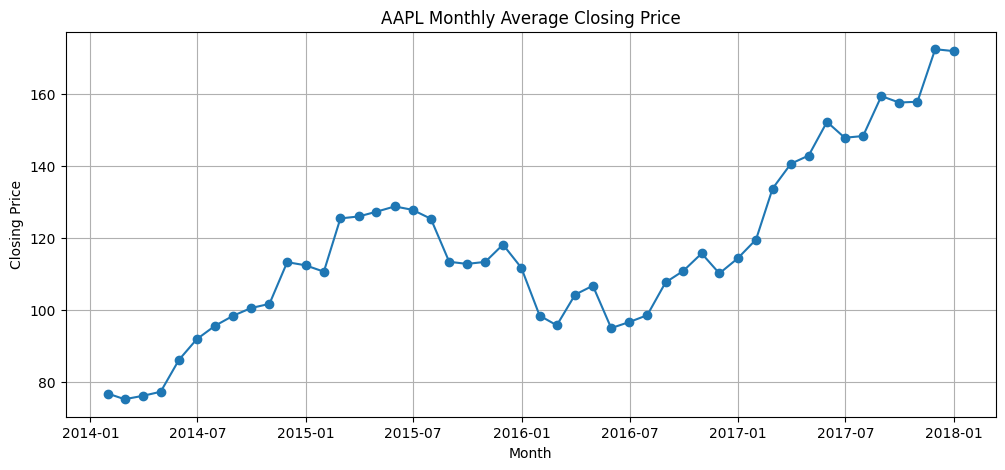

In [75]:
plt.figure(figsize=(12,5))
plt.plot(monthly_stock, marker="o")
plt.title(f"{stock_symbol} Monthly Average Closing Price")
plt.xlabel("Month")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

1. It helps to identify smoother trends
2. Long term investors can identify their potential long terms wealth building stocks becauses it does not  contain short term fluctuations.
3. Overall in Month, the investors can get a clear picture of the summary performance of stocks.

### Trend Decomposition

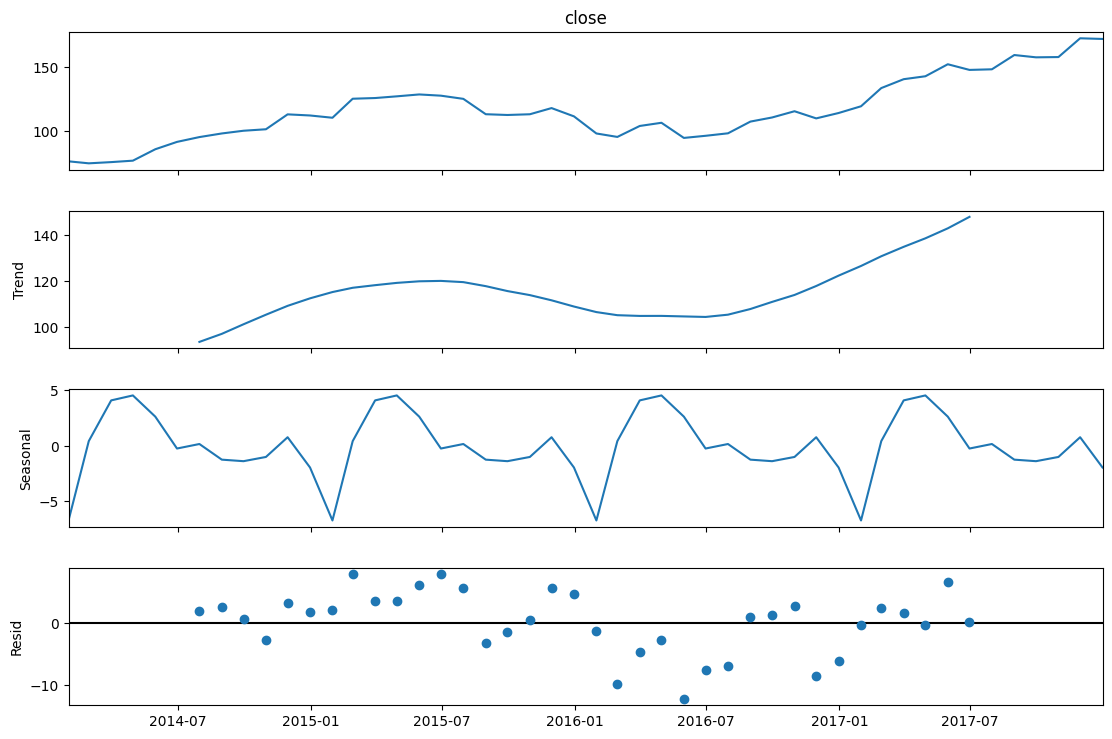

In [76]:
decomposition = seasonal_decompose(monthly_stock,
                                     model="additive",
                                     period=12)


fig = decomposition.plot()# Plot decomposition
fig.set_size_inches(12, 8)
plt.show()

1. The trendline shows the stocks overall growth over time
2. Seasons has it impact but compared to yearly trend it is minimal
   

### Forecast next 30 trading days

In [77]:
daily_close = stock_df["close"].dropna()

# Train ARIMA model
arima_model = ARIMA(daily_close, order=(5,1,0))
arima_result = arima_model.fit()

# Forecast next 30 trading days
forecast = arima_result.forecast(steps=30)

forecast.head()

c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\abhin\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is ava

1007    169.087306
1008    169.027537
1009    169.108869
1010    169.091223
1011    169.048889
Name: predicted_mean, dtype: float64

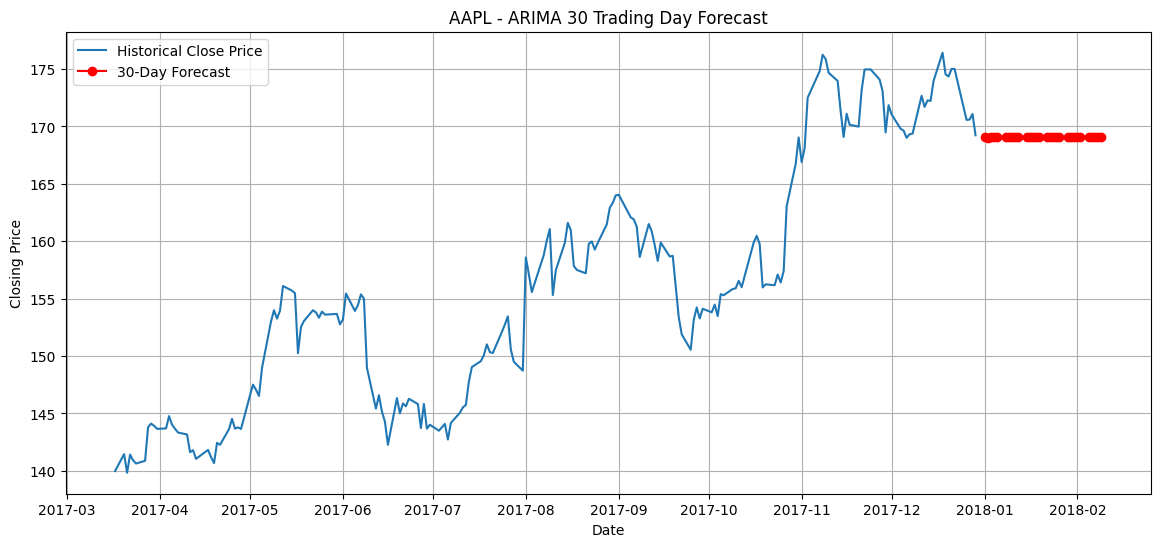

In [78]:
plt.figure(figsize=(14,6))

# Historical data (last 200 days for better visibility)
plt.plot(daily_close.tail(200), label="Historical Close Price")# Historical data (last 200 days for better visibility)

future_dates = pd.bdate_range(start=daily_close.index[-1] + pd.Timedelta(days=1),
# Create future dates
                              periods=30)


plt.plot(future_dates, forecast,# Plot forecast
         color="red", marker="o",
         label="30-Day Forecast")

plt.title(f"{stock_symbol} - ARIMA 30 Trading Day Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

1. It uses ARIMA model to forecast next 30 days  closing price
2. It provides analytical data nd the prices that should be using hiostorical data.
3. It helps in taking better decisions whether to invest in a stock within a particcular period.
4. It also helps to decide whether ist the right time to sell the stock within a particular period.

In [79]:
forecast_df = pd.DataFrame({
    "Forecast_Date": future_dates,
    "Predicted_Close": forecast.values
})

forecast_df.head(30)  # Forcasted 30 days

,Forecast_Date,Predicted_Close
0,2018-01-01,169.087306
1,2018-01-02,169.027537
2,2018-01-03,169.108869
3,2018-01-04,169.091223
4,2018-01-05,169.048889
5,2018-01-08,169.041300
6,2018-01-09,169.043370
7,2018-01-10,169.046565
8,2018-01-11,169.045646
9,2018-01-12,169.044415


# Business Insights


1. REGN stocks gives the highest daily return.
2. The S&P 500 companies are moving towards a positive trend which suggests long-term growth.
3. The companies faced fluctuations in certain months, but the growth trajectory still remains steady.

4. The closing price from 2016 to 2017 suggests strong growth.

5. The distribution of the data remains very close to 0, which shows that the daily returns are not spread very far, which portrays the stocks to be less volatile.

6. With the box plot, it is identified that most of the stocks' daily returns remain near the median, which suggests lower volatility.

7. There are some stocks whose daily returns are outliers, as can be seen in the box plot, which can be because of unregulated funds, stock manipulation, or market news. These stocks seen as outliers do not have a major impact on the other stable stocks and can be avoided.

8. Through correlation, it can be said that the open, high, low, and close prices are highly connected to one another. With their highly correlated data, it is showing a positive trend. The possibility of two or three of the variables (open, low, high, close) moving in any direction can give a better prediction towards the moving trend.

9. Any new market news, change of directors, or change of price could have its impact on the open, low, high, and close prices equally and could lead to positive or negative trend movement.

10. S&P 500 companies' open and close prices show an upward trend, which suggests strong stability and continuous future growth.

11. Few outliers exist, but eventually they also portray positive growth.

12. The moving average taken for 7 days suggests that stocks are good to buy.

13. The 7-day moving average crossing the 30-day moving average can be an indicator to invest in stocks, as its historical data suggests.

14. The quarterly trading volume of stocks suggests liquidity. It means the stocks can be sold or bought according to market timing.

15. Its highest liquidity was in 2016 Q1, but it tends to see a decline in volume; however, it did not affect the growth of the stocks.

16. The maximum price difference of the 500 stocks remains close to one another from the start to the end of the analysis period, which suggests stable prices and minimal fluctuations, providing a safety net for new investments.

17. There are very few outliers, which suggests that they do not have a major impact on the timely growth of stocks.

18. Rolling standard deviation gives insights into market volatility.

19. Higher volatility can be treated as the involvement of short-term risk.

20. Random Forest model is chosen because it gave the least(mae,mse,rmse and mape)

21. AAPL stock's monthly growth suggests that it has its lows but still gives better returns over the long term, so it is a great stock investment.

22. Trend decomposition shows that price fluctuations are short term, whereas overall growth is stable and trending.

23. Compare stocks quarterly and avoid monthly comparison for a better picture.

24. The ARIMA model successfully generated the 30-day forecast, which gives insights for better decision-making.

25. The forecasting data can be used to compare stocks along with low price difference and low volatility to identify better investment stocks.

26. Overall, S&P 500 stocks show steady and healthy growth over the long term and not the short term. There are fluctuations (short term) and outliers, but they do not have a major impact on the direction of long-term investment and growth. Avoiding short-term investing and planning investments in these stocks for the long term will suggest a positive trend.


# Challenges

### Challenge 1
Find the Top 10 most volatile stocks.

In [86]:
top_10_volatile =df.groupby("symbol")["rolling_std_5"].mean().sort_values(ascending = False)
top_10_volatile.head(10)


symbol
REGN    0.033370
CHK     0.032343
AMD     0.025894
FCX     0.024571
RRC     0.023571
INCY    0.023325
VRTX    0.021614
NFX     0.021504
MRO     0.020668
NRG     0.020363
Name: rolling_std_5, dtype: float64

### Challenge 2
Calculate 30-day moving averages for every stock.

In [87]:
df["moving_average"] = df.groupby("symbol")["close"].transform(lambda x : x.rolling(30).mean())